In [2]:
from google.colab import files

uploaded = files.upload()

Saving DroneAcharaya-main.zip to DroneAcharaya-main.zip


In [3]:
!unzip -q DroneAcharaya-main.zip

In [6]:
# Cell 0 — Imports

import gc
import os
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [2]:
from google.colab import drive

drive.mount("/content/drive")

DATA_RAW_DIR = "/content/drive/MyDrive/DroneAcharaya/ml_artifacts/xgboost_classifier/raw"
ARTIFACTS_DIR = "/content/drive/MyDrive/DroneAcharaya/ml_artifacts/xgboost_classifier"

os.makedirs(ARTIFACTS_DIR, exist_ok=True)

print("Data directory:", DATA_RAW_DIR)
print("Artifacts directory:", ARTIFACTS_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data directory: /content/drive/MyDrive/DroneAcharaya/ml_artifacts/xgboost_classifier/raw
Artifacts directory: /content/drive/MyDrive/DroneAcharaya/ml_artifacts/xgboost_classifier


In [7]:
# Cell 3 — Check that all required files exist

required_files = [
    "telemetry_train.csv",
    "telemetry_validation.csv",
    "groundtruth_train.csv",
    "groundtruth_validation.csv",
]

for filename in required_files:
    path = os.path.join(DATA_RAW_DIR, filename)

    print(
        f"{filename}:",
        "FOUND" if os.path.exists(path) else "MISSING"
    )

telemetry_train.csv: FOUND
telemetry_validation.csv: FOUND
groundtruth_train.csv: FOUND
groundtruth_validation.csv: FOUND


In [8]:

_TELEMETRY_NON_NUMERIC = {
    "run_id",
    "engine_state",
    "engine_id",
    "mission_id",
    "data_origin",
}

_GT_NON_NUMERIC = {
    "run_id",
    "sensor_fault_active_cht_c3",
    "sensor_fault_active_vibration_rms_x_bearing_proxy",
}


def _read_csv_f32(path, non_numeric_cols):
    header_cols = pd.read_csv(path, nrows=0).columns

    dtype_map = {
        c: "float32"
        for c in header_cols
        if c not in non_numeric_cols and c != "t"
    }

    return pd.read_csv(path, dtype=dtype_map)


telemetry_train_df = _read_csv_f32(
    f"{DATA_RAW_DIR}/telemetry_train.csv",
    _TELEMETRY_NON_NUMERIC,
)

gt_train_df = _read_csv_f32(
    f"{DATA_RAW_DIR}/groundtruth_train.csv",
    _GT_NON_NUMERIC,
)

telemetry_val_df = _read_csv_f32(
    f"{DATA_RAW_DIR}/telemetry_validation.csv",
    _TELEMETRY_NON_NUMERIC,
)

gt_val_df = _read_csv_f32(
    f"{DATA_RAW_DIR}/groundtruth_validation.csv",
    _GT_NON_NUMERIC,
)

print("Telemetry train:", telemetry_train_df.shape)
print("Groundtruth train:", gt_train_df.shape)
print("Telemetry validation:", telemetry_val_df.shape)
print("Groundtruth validation:", gt_val_df.shape)

Telemetry train: (2840460, 40)
Groundtruth train: (2840460, 49)
Telemetry validation: (797785, 40)
Groundtruth validation: (797785, 49)


In [9]:
telemetry_df = pd.concat(
    [telemetry_train_df, telemetry_val_df],
    ignore_index=True,
)

gt_df = pd.concat(
    [gt_train_df, gt_val_df],
    ignore_index=True,
)

train_run_ids = set(
    telemetry_train_df["run_id"].unique()
)

del telemetry_train_df
del gt_train_df
del telemetry_val_df
del gt_val_df

gc.collect()

print("Telemetry:", telemetry_df.shape)
print("Groundtruth:", gt_df.shape)
print("Number of training runs:", len(train_run_ids))

Telemetry: (3638245, 40)
Groundtruth: (3638245, 49)
Number of training runs: 1312


In [10]:
merged_df = pd.merge(
    telemetry_df,
    gt_df,
    on=["run_id", "t"],
    how="inner",
    validate="one_to_one",
)

assert len(merged_df) == len(telemetry_df), (
    "Row count changed after merge — check join key alignment"
)

del telemetry_df
del gt_df

gc.collect()

print("Merged:", merged_df.shape)

Merged: (3638245, 87)


In [11]:
SENSOR_COLUMNS = [
    "rpm",
    "torque",
    "power",
    "engine_load",
    "cht_c1",
    "cht_c2",
    "cht_c3",
    "cht_c4",
    "egt_c1",
    "egt_c2",
    "egt_c3",
    "egt_c4",
    "oil_pressure",
    "oil_temperature",
    "fuel_flow",
    "rail_pressure",
    "injection_timing",
    "boost_pressure",
    "map",
    "intake_temperature",
    "air_mass_flow",
    "coolant_temperature",
    "vibration_rms_x",
    "vibration_order_1x",
    "vibration_rms_x_bearing_proxy",
    "vibration_order_1x_bearing_proxy",
    "battery_voltage",
    "battery_current",
    "alternator_power",
    "altitude",
    "ambient_pressure",
    "ambient_temperature",
    "air_density",
    "throttle",
]

SENSOR_FAULT_COLUMNS = [
    c
    for c in merged_df.columns
    if c.startswith("sensor_fault_active_")
]

print("Detected sensor-fault columns:")
print(SENSOR_FAULT_COLUMNS)

Detected sensor-fault columns:
['sensor_fault_active_cht_c3', 'sensor_fault_active_vibration_rms_x_bearing_proxy']


In [12]:
for col in SENSOR_FAULT_COLUMNS:
    print(f"\n{col}")
    print(merged_df[col].value_counts(dropna=False))


sensor_fault_active_cht_c3
sensor_fault_active_cht_c3
NONE     3288992
DRIFT     136170
NOISE      77323
BIAS       70810
STUCK      64950
Name: count, dtype: int64

sensor_fault_active_vibration_rms_x_bearing_proxy
sensor_fault_active_vibration_rms_x_bearing_proxy
NONE       3635600
DROPOUT       2645
Name: count, dtype: int64


In [13]:
SENSOR_FAULT_CLASSES = [
    "NONE",
    "BIAS",
    "DRIFT",
    "NOISE",
    "STUCK",
    "DROPOUT",
]

sensor_fault_class_map = {
    c: i
    for i, c in enumerate(SENSOR_FAULT_CLASSES)
}

for col in SENSOR_FAULT_COLUMNS:
    merged_df[col] = merged_df[col].map(sensor_fault_class_map).astype("int8")

print(merged_df[SENSOR_FAULT_COLUMNS].head())
print("\nEncoded dtypes:")
print(merged_df[SENSOR_FAULT_COLUMNS].dtypes)

   sensor_fault_active_cht_c3  \
0                           0   
1                           0   
2                           0   
3                           0   
4                           0   

   sensor_fault_active_vibration_rms_x_bearing_proxy  
0                                                  0  
1                                                  0  
2                                                  0  
3                                                  0  
4                                                  0  

Encoded dtypes:
sensor_fault_active_cht_c3                           int8
sensor_fault_active_vibration_rms_x_bearing_proxy    int8
dtype: object


In [14]:
ROLLING_FAULT_PRONE_COLUMNS = [
    "cht_c3",
    "vibration_rms_x_bearing_proxy",
]

ROLLING_WINDOW = 10  # seconds, dataset is 1 Hz


def add_rolling_features(
    df: pd.DataFrame,
    cols: list[str],
    window: int,
) -> pd.DataFrame:

    df = df.sort_values(["run_id", "t"])

    grouped = df.groupby(
        "run_id",
        sort=False,
    )

    for col in cols:

        roll = grouped[col].rolling(
            window=window,
            min_periods=1,
        )

        roll_mean = (
            roll.mean()
            .reset_index(level=0, drop=True)
        )

        roll_std = (
            roll.std()
            .reset_index(level=0, drop=True)
        )

        df[f"{col}_roll_mean"] = roll_mean

        df[f"{col}_roll_std"] = (
            roll_std.fillna(0.0)
        )

        df[f"{col}_dev_from_roll_mean"] = (
            df[col] - roll_mean
        )

        df[f"{col}_diff"] = (
            grouped[col]
            .diff()
            .fillna(0.0)
        )

        is_same_as_prev = (
            grouped[col]
            .diff()
            .fillna(1.0)
            == 0.0
        )

        stuck_run_id = (
            (~is_same_as_prev)
            .groupby(df["run_id"])
            .cumsum()
        )

        df[f"{col}_stuck_run_length"] = (
            df.groupby(
                ["run_id", stuck_run_id]
            )
            .cumcount()
            + 1
        )

    return df


merged_df = add_rolling_features(
    merged_df,
    ROLLING_FAULT_PRONE_COLUMNS,
    ROLLING_WINDOW,
)

ROLLING_FEATURE_COLUMNS = [
    f"{col}_{suffix}"
    for col in ROLLING_FAULT_PRONE_COLUMNS
    for suffix in [
        "roll_mean",
        "roll_std",
        "dev_from_roll_mean",
        "diff",
        "stuck_run_length",
    ]
]

print(
    f"{len(ROLLING_FEATURE_COLUMNS)} rolling features added"
)

10 rolling features added


In [15]:
import joblib

train_mask = merged_df["run_id"].isin(
    train_run_ids
)

NAN_PRONE_SENSOR_COLUMNS = [
    "vibration_rms_x",
    "vibration_order_1x",
    "vibration_rms_x_bearing_proxy",
]

MISSING_FLAG_COLUMNS = [
    f"{col}_missing"
    for col in NAN_PRONE_SENSOR_COLUMNS
]

for col, flag_col in zip(
    NAN_PRONE_SENSOR_COLUMNS,
    MISSING_FLAG_COLUMNS,
):
    merged_df[flag_col] = (
        merged_df[col]
        .isna()
        .astype(np.float32)
    )

SCALE_COLUMNS = (
    SENSOR_COLUMNS
    + ROLLING_FEATURE_COLUMNS
)

scaler = StandardScaler()

scaler.fit(
    merged_df.loc[
        train_mask,
        SCALE_COLUMNS,
    ]
)

joblib.dump(
    scaler,
    f"{ARTIFACTS_DIR}/scaler.joblib",
)

merged_df[SCALE_COLUMNS] = (
    scaler.transform(
        merged_df[SCALE_COLUMNS]
    )
)

merged_df[NAN_PRONE_SENSOR_COLUMNS] = (
    merged_df[NAN_PRONE_SENSOR_COLUMNS]
    .fillna(0.0)
)

merged_df[SCALE_COLUMNS] = (
    merged_df[SCALE_COLUMNS]
    .fillna(0.0)
)

assert not merged_df[
    SCALE_COLUMNS
].isna().any().any(), (
    "NaNs remain in SCALE_COLUMNS after fill"
)

engine_state_encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False,
    dtype=np.float32,
)

engine_state_encoder.fit(
    merged_df.loc[
        train_mask,
        ["engine_state"],
    ]
)

engine_state_encoded = (
    engine_state_encoder.transform(
        merged_df[["engine_state"]]
    )
)

engine_state_col_names = (
    engine_state_encoder
    .get_feature_names_out(
        ["engine_state"]
    )
    .tolist()
)

for i, col_name in enumerate(
    engine_state_col_names
):
    merged_df[col_name] = (
        engine_state_encoded[:, i]
    )

del engine_state_encoded

gc.collect()

joblib.dump(
    engine_state_encoder,
    f"{ARTIFACTS_DIR}/engine_state_encoder.joblib",
)

print(
    "Engine state columns:",
    engine_state_col_names,
)

Engine state columns: ['engine_state_CLIMB', 'engine_state_CRUISE', 'engine_state_DESCENT', 'engine_state_HIGH_ALTITUDE_CRUISE', 'engine_state_IDLE', 'engine_state_LOITER', 'engine_state_SHUTDOWN', 'engine_state_STARTING', 'engine_state_THROTTLE_TRANSIENT']


In [16]:
XGB_FEATURE_COLUMNS = (
    SENSOR_COLUMNS
    + MISSING_FLAG_COLUMNS
    + ROLLING_FEATURE_COLUMNS
    + engine_state_col_names
)

X_train = merged_df.loc[
    train_mask,
    XGB_FEATURE_COLUMNS,
].values

X_val = merged_df.loc[
    ~train_mask,
    XGB_FEATURE_COLUMNS,
].values

print(
    f"{len(XGB_FEATURE_COLUMNS)} input features"
)

print(
    f"{len(SENSOR_FAULT_COLUMNS)} target channels, "
    f"{len(SENSOR_FAULT_CLASSES)} classes each"
)

print(
    "Train:",
    X_train.shape,
    "| Val:",
    X_val.shape,
)

56 input features
2 target channels, 6 classes each
Train: (2840460, 56) | Val: (797785, 56)


In [17]:
y_train = {
    col: merged_df.loc[train_mask, col].values
    for col in SENSOR_FAULT_COLUMNS
}

y_val = {
    col: merged_df.loc[~train_mask, col].values
    for col in SENSOR_FAULT_COLUMNS
}

for col in SENSOR_FAULT_COLUMNS:
    print(f"\n{col}")
    print("Train:", y_train[col].shape)
    print("Val:  ", y_val[col].shape)
    print("Train classes:", np.unique(y_train[col], return_counts=True))
    print("Val classes:  ", np.unique(y_val[col], return_counts=True))


sensor_fault_active_cht_c3
Train: (2840460,)
Val:   (797785,)
Train classes: (array([0, 1, 2, 3, 4], dtype=int8), array([2583848,   55655,  102217,   55348,   43392]))
Val classes:   (array([0, 1, 2, 3, 4], dtype=int8), array([705144,  15155,  33953,  21975,  21558]))

sensor_fault_active_vibration_rms_x_bearing_proxy
Train: (2840460,)
Val:   (797785,)
Train classes: (array([0, 5], dtype=int8), array([2838301,    2159]))
Val classes:   (array([0, 5], dtype=int8), array([797299,    486]))


In [18]:

sensor_fault_class_weights = {}

for channel_col in SENSOR_FAULT_COLUMNS:
    y_train_channel = merged_df.loc[
        train_mask,
        channel_col,
    ].astype(int).values

    class_counts = Counter(y_train_channel)

    total = len(y_train_channel)
    n_classes = len(SENSOR_FAULT_CLASSES)

    class_weights = {}

    for class_id in range(n_classes):
        count = class_counts.get(class_id, 0)

        if count > 0:
            class_weights[class_id] = total / (n_classes * count)
        else:
            class_weights[class_id] = 0.0

    sensor_fault_class_weights[channel_col] = class_weights

    print(f"\n{channel_col}")
    print("Class counts:", dict(sorted(class_counts.items())))
    print("Class weights:", class_weights)


sensor_fault_active_cht_c3
Class counts: {np.int64(0): 2583848, np.int64(1): 55655, np.int64(2): 102217, np.int64(3): 55348, np.int64(4): 43392}
Class weights: {0: 0.18321898192153718, 1: 8.506153984367982, 2: 4.63142138783177, 3: 8.553335260533352, 4: 10.910075589970502, 5: 0.0}

sensor_fault_active_vibration_rms_x_bearing_proxy
Class counts: {np.int64(0): 2838301, np.int64(5): 2159}
Class weights: {0: 0.16679344438803353, 1: 0.0, 2: 0.0, 3: 0.0, 4: 0.0, 5: 219.27281148679944}


In [19]:
target_label_maps = {}
target_inverse_maps = {}

for col in SENSOR_FAULT_COLUMNS:
    classes_present = np.sort(np.unique(y_train[col]))

    target_label_maps[col] = {
        int(original): int(i)
        for i, original in enumerate(classes_present)
    }

    target_inverse_maps[col] = {
        int(i): int(original)
        for i, original in enumerate(classes_present)
    }

    print(f"\n{col}")
    print("Original → XGBoost:", target_label_maps[col])
    print("XGBoost → Original:", target_inverse_maps[col])


sensor_fault_active_cht_c3
Original → XGBoost: {0: 0, 1: 1, 2: 2, 3: 3, 4: 4}
XGBoost → Original: {0: 0, 1: 1, 2: 2, 3: 3, 4: 4}

sensor_fault_active_vibration_rms_x_bearing_proxy
Original → XGBoost: {0: 0, 5: 1}
XGBoost → Original: {0: 0, 1: 5}


In [20]:
y_train_xgb = {}
y_val_xgb = {}
sample_weights_xgb = {}

for col in SENSOR_FAULT_COLUMNS:

    # Remap original labels to contiguous 0...K-1 labels
    label_map = target_label_maps[col]

    y_train_xgb[col] = np.array(
        [label_map[int(y)] for y in y_train[col]],
        dtype=np.int32,
    )

    y_val_xgb[col] = np.array(
        [label_map.get(int(y), -1) for y in y_val[col]],
        dtype=np.int32,
    )

    # Convert original class weights to remapped class IDs
    sample_weights_xgb[col] = np.array(
        [
            sensor_fault_class_weights[col][
                target_inverse_maps[col][int(y)]
            ]
            for y in y_train_xgb[col]
        ],
        dtype=np.float32,
    )

    print(
        f"\n{col}"
        f"\nTrain labels: {np.unique(y_train_xgb[col])}"
        f"\nVal labels:   {np.unique(y_val_xgb[col])}"
        f"\nWeights shape: {sample_weights_xgb[col].shape}"
    )


sensor_fault_active_cht_c3
Train labels: [0 1 2 3 4]
Val labels:   [0 1 2 3 4]
Weights shape: (2840460,)

sensor_fault_active_vibration_rms_x_bearing_proxy
Train labels: [0 1]
Val labels:   [0 1]
Weights shape: (2840460,)


In [22]:
xgb_models = {}

for i, col in enumerate(SENSOR_FAULT_COLUMNS, start=1):

    n_classes = len(target_label_maps[col])

    print(f"\nTraining XGBoost {i}")
    print(f"Target: {col}")
    print(f"Number of classes: {n_classes}")

    model = xgb.XGBClassifier(
        n_estimators=500,
        max_depth=8,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="multi:softprob",
        num_class=n_classes,
        eval_metric=["mlogloss", "merror"],
        tree_method="hist",
        random_state=42,
        n_jobs=-1,
        early_stopping_rounds=30,
    )

    model.fit(
        X_train,
        y_train_xgb[col],
        sample_weight=sample_weights_xgb[col],

        eval_set=[
            (X_train, y_train_xgb[col]),
            (X_val, y_val_xgb[col]),
        ],

        verbose=50,
    )

    xgb_models[col] = model

    print(f"XGBoost {i} training complete.")
    print(f"Best iteration: {model.best_iteration}")
    print(f"Best validation score: {model.best_score}")


Training XGBoost 1
Target: sensor_fault_active_cht_c3
Number of classes: 5
[0]	validation_0-mlogloss:1.51202	validation_0-merror:0.04708	validation_1-mlogloss:1.51476	validation_1-merror:0.06832
[30]	validation_0-mlogloss:0.56836	validation_0-merror:0.07117	validation_1-mlogloss:0.59799	validation_1-merror:0.09195
XGBoost 1 training complete.
Best iteration: 0
Best validation score: 0.06831790520002257

Training XGBoost 2
Target: sensor_fault_active_vibration_rms_x_bearing_proxy
Number of classes: 2
[0]	validation_0-mlogloss:0.65465	validation_0-merror:0.00000	validation_1-mlogloss:0.65465	validation_1-merror:0.00000
[30]	validation_0-mlogloss:0.11173	validation_0-merror:0.00000	validation_1-mlogloss:0.11174	validation_1-merror:0.00000
XGBoost 2 training complete.
Best iteration: 0
Best validation score: 0.0


In [23]:
TEST_RUN_ID = "UNIT-sensorfaultdemodrift-0009_M002"

run_mask = merged_df["run_id"] == TEST_RUN_ID

X_real_run = merged_df.loc[
    run_mask,
    XGB_FEATURE_COLUMNS,
].values

actual_fault = merged_df.loc[
    run_mask,
    "sensor_fault_active_cht_c3",
].values

print("Run:", TEST_RUN_ID)
print("Rows:", len(X_real_run))
print("Actual fault classes:", np.unique(actual_fault, return_counts=True))

# XGBoost prediction probabilities
proba = xgb_models[
    "sensor_fault_active_cht_c3"
].predict_proba(X_real_run)

pred_xgb = np.argmax(proba, axis=1)

# Convert XGBoost class IDs back to original IDs
inverse_map = target_inverse_maps[
    "sensor_fault_active_cht_c3"
]

pred_original = np.array(
    [inverse_map[int(p)] for p in pred_xgb],
    dtype=np.int8,
)

print("\nPredicted classes:", np.unique(
    pred_original,
    return_counts=True,
))

print("\nFirst 20 predictions:")
print(pred_original[:20])

Run: UNIT-sensorfaultdemodrift-0009_M002
Rows: 1486
Actual fault classes: (array([2], dtype=int8), array([1486]))

Predicted classes: (array([0, 1, 2], dtype=int8), array([498, 656, 332]))

First 20 predictions:
[0 0 0 0 0 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2]


In [24]:

for channel_col, model in xgb_models.items():

    # Original validation labels
    y_val_channel = merged_df.loc[
        ~train_mask,
        channel_col,
    ].astype(int).values

    # Get probability predictions
    proba = model.predict_proba(X_val)

    # Convert probabilities → XGBoost class IDs
    pred_xgb = np.argmax(proba, axis=1)

    # Convert back to original class IDs
    inverse_map = target_inverse_maps[channel_col]

    y_pred = np.array(
        [inverse_map[int(p)] for p in pred_xgb],
        dtype=np.int8,
    )

    # Only classes that actually exist for this channel
    present_classes = sorted(
        np.unique(y_val_channel)
    )

    target_names = [
        SENSOR_FAULT_CLASSES[class_id]
        for class_id in present_classes
    ]

    print("\n" + "=" * 80)
    print(channel_col)
    print("=" * 80)

    print(
        classification_report(
            y_val_channel,
            y_pred,
            labels=present_classes,
            target_names=target_names,
            zero_division=0,
        )
    )


sensor_fault_active_cht_c3
              precision    recall  f1-score   support

        NONE       0.97      0.96      0.97    705144
        BIAS       0.43      0.44      0.43     15155
       DRIFT       0.36      0.42      0.39     33953
       NOISE       1.00      1.00      1.00     21975
       STUCK       1.00      1.00      1.00     21558

    accuracy                           0.93    797785
   macro avg       0.75      0.76      0.76    797785
weighted avg       0.94      0.93      0.93    797785


sensor_fault_active_vibration_rms_x_bearing_proxy
              precision    recall  f1-score   support

        NONE       1.00      1.00      1.00    797299
     DROPOUT       1.00      1.00      1.00       486

    accuracy                           1.00    797785
   macro avg       1.00      1.00      1.00    797785
weighted avg       1.00      1.00      1.00    797785



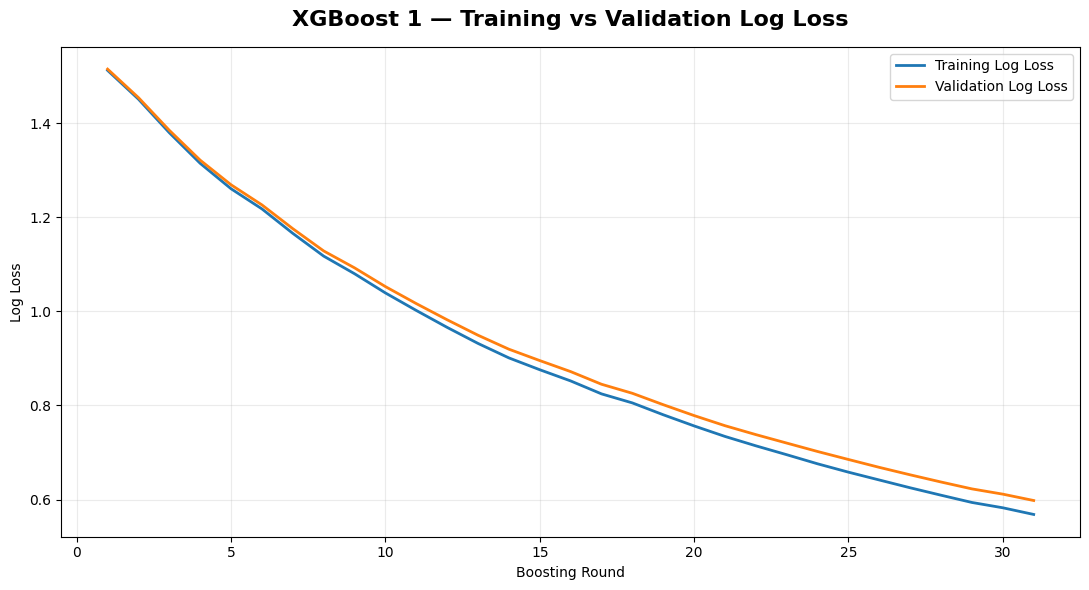

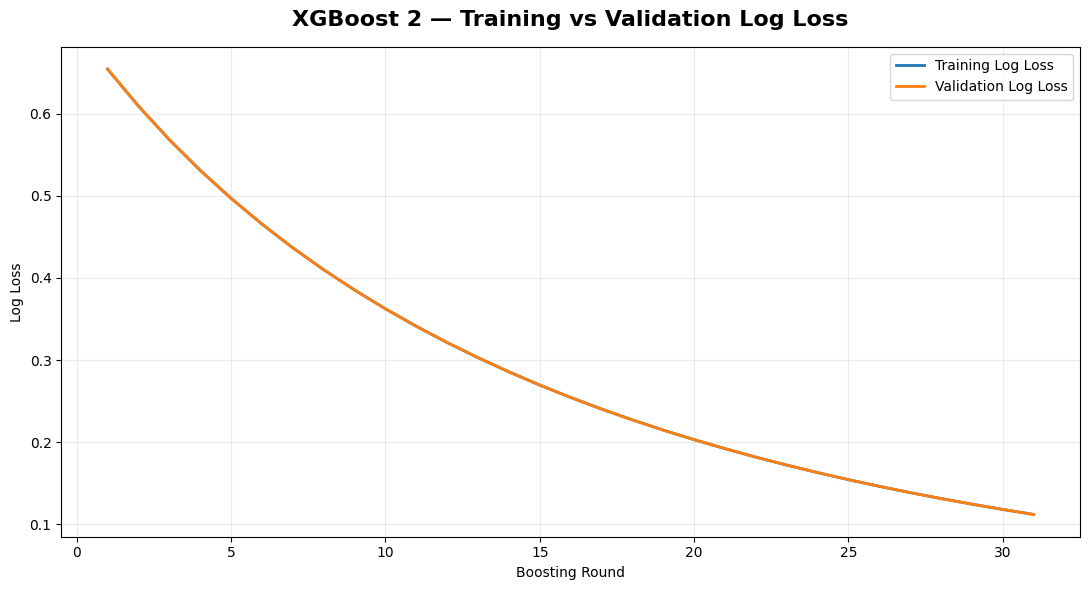

In [28]:

for i, (channel_col, model) in enumerate(
    xgb_models.items(),
    start=1,
):

    results = model.evals_result()

    train_loss = np.array(
        results["validation_0"]["mlogloss"]
    )

    val_loss = np.array(
        results["validation_1"]["mlogloss"]
    )

    rounds = np.arange(1, len(train_loss) + 1)

    plt.figure(figsize=(11, 6))

    plt.plot(
        rounds,
        train_loss,
        linewidth=2,
        label="Training Log Loss",
    )

    plt.plot(
        rounds,
        val_loss,
        linewidth=2,
        label="Validation Log Loss",
    )

    plt.xlabel("Boosting Round")
    plt.ylabel("Log Loss")

    plt.title(
        f"XGBoost {i} — Training vs Validation Log Loss",
        fontsize=16,
        fontweight="bold",
        pad=15,
    )

    plt.grid(True, alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()

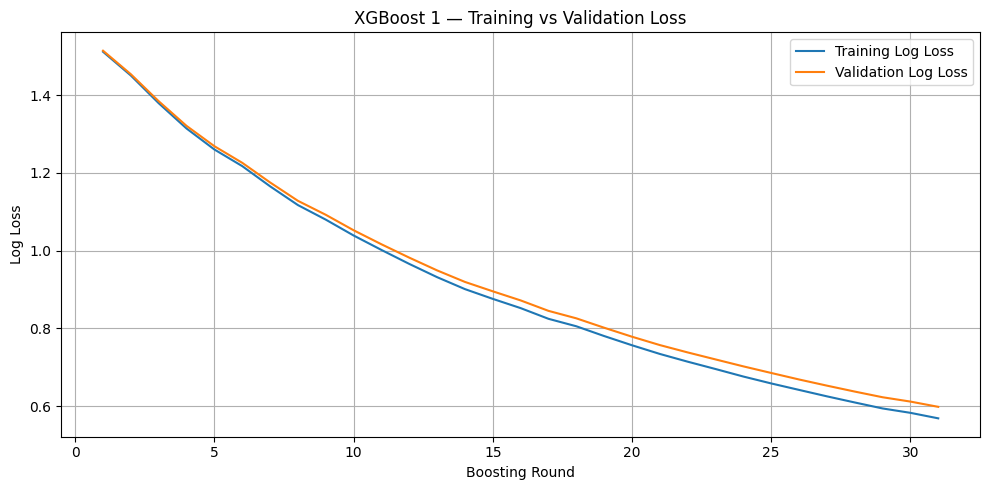

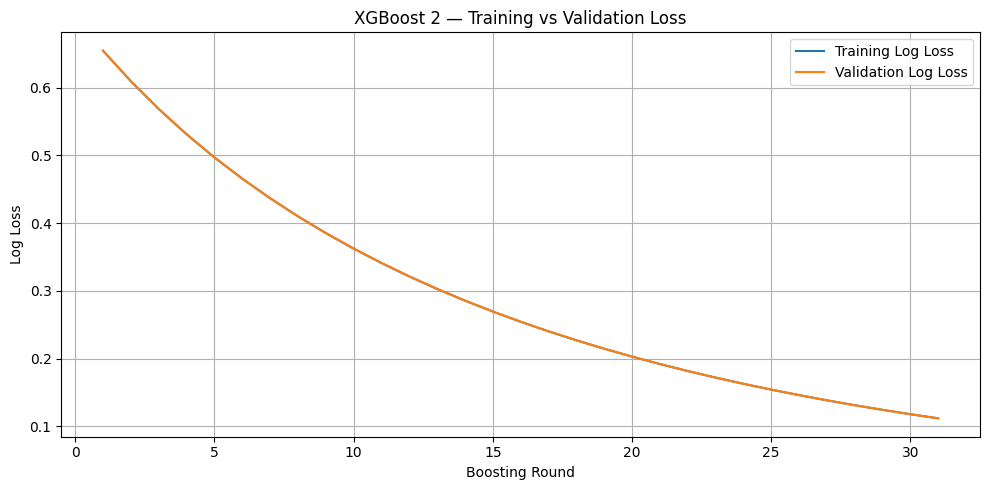

In [29]:
for i, (channel_col, model) in enumerate(
    xgb_models.items(),
    start=1,
):

    results = model.evals_result()

    train_loss = results["validation_0"]["mlogloss"]
    val_loss = results["validation_1"]["mlogloss"]

    rounds = range(1, len(train_loss) + 1)

    plt.figure(figsize=(10, 5))

    plt.plot(
        rounds,
        train_loss,
        label="Training Log Loss",
    )

    plt.plot(
        rounds,
        val_loss,
        label="Validation Log Loss",
    )

    plt.xlabel("Boosting Round")
    plt.ylabel("Log Loss")

    plt.title(
        f"XGBoost {i} — Training vs Validation Loss"
    )

    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

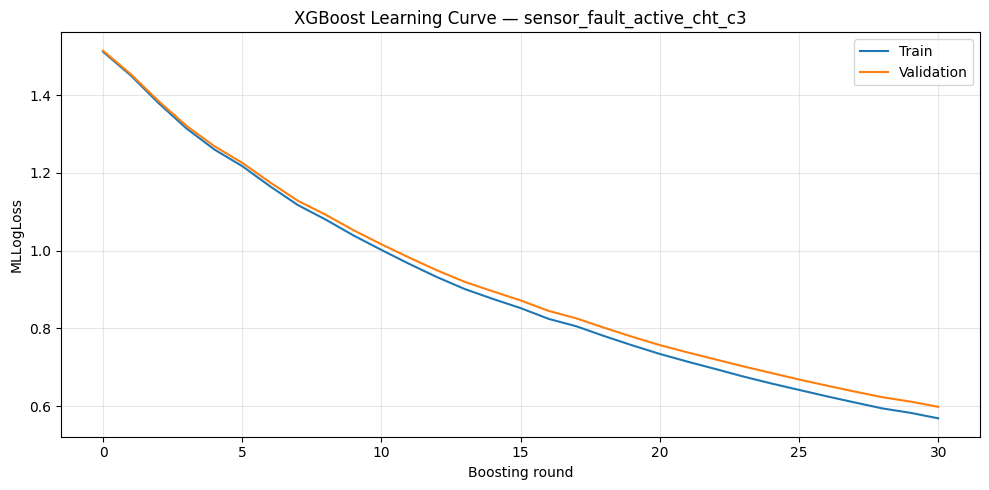

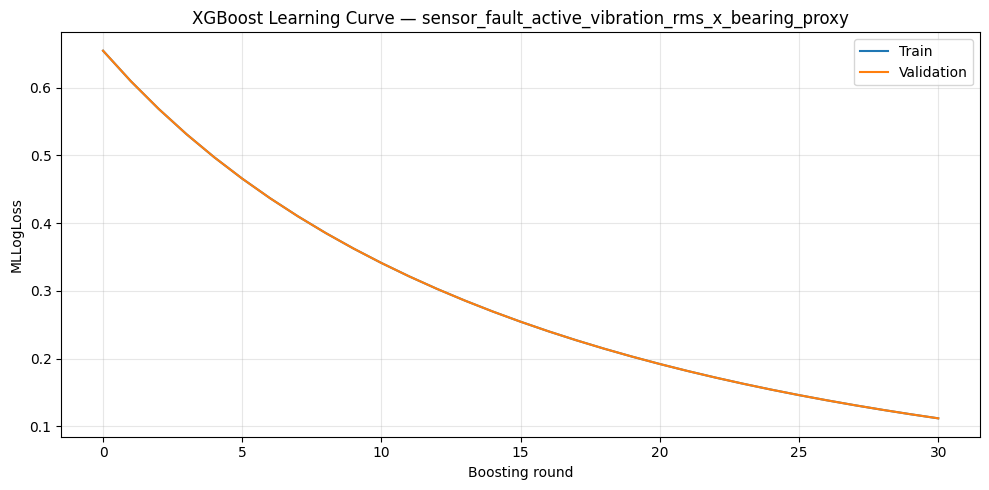

In [30]:
for channel_col, model in xgb_models.items():

    results = model.evals_result()

    train_loss = results["validation_0"]["mlogloss"]
    val_loss = results["validation_1"]["mlogloss"]

    plt.figure(figsize=(10, 5))

    plt.plot(train_loss, label="Train")
    plt.plot(val_loss, label="Validation")

    plt.xlabel("Boosting round")
    plt.ylabel("MLLogLoss")

    plt.title(
        f"XGBoost Learning Curve — {channel_col}"
    )

    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

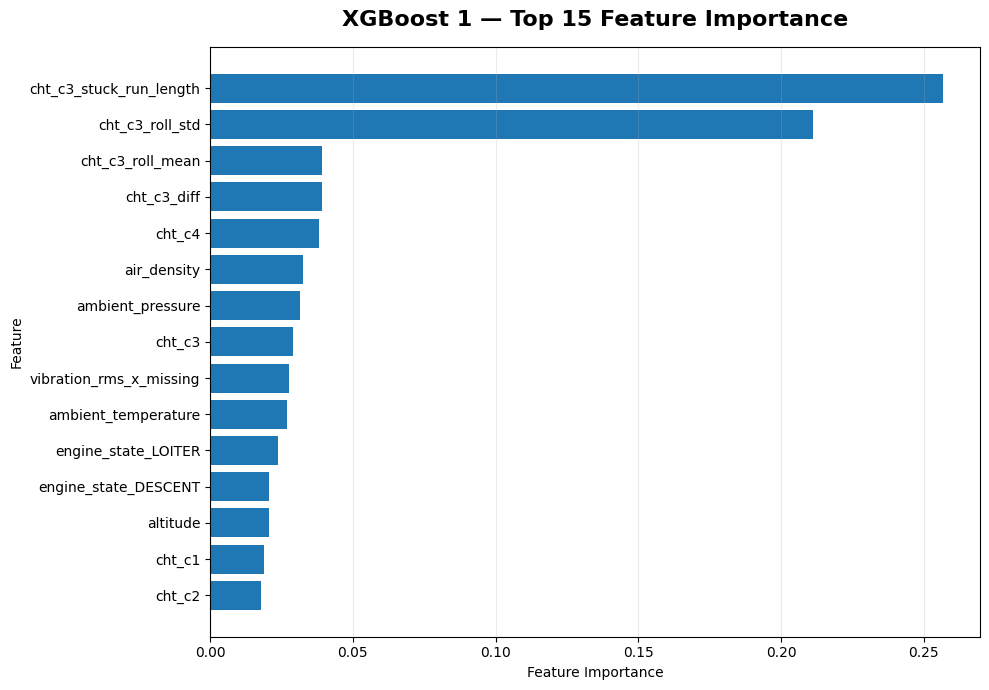


XGBoost 1 — Top 15 Features
                Feature  Importance
cht_c3_stuck_run_length    0.256877
        cht_c3_roll_std    0.211221
       cht_c3_roll_mean    0.039356
            cht_c3_diff    0.039230
                 cht_c4    0.038113
            air_density    0.032690
       ambient_pressure    0.031589
                 cht_c3    0.028873
vibration_rms_x_missing    0.027794
    ambient_temperature    0.026946
    engine_state_LOITER    0.023632
   engine_state_DESCENT    0.020504
               altitude    0.020488
                 cht_c1    0.018987
                 cht_c2    0.017988


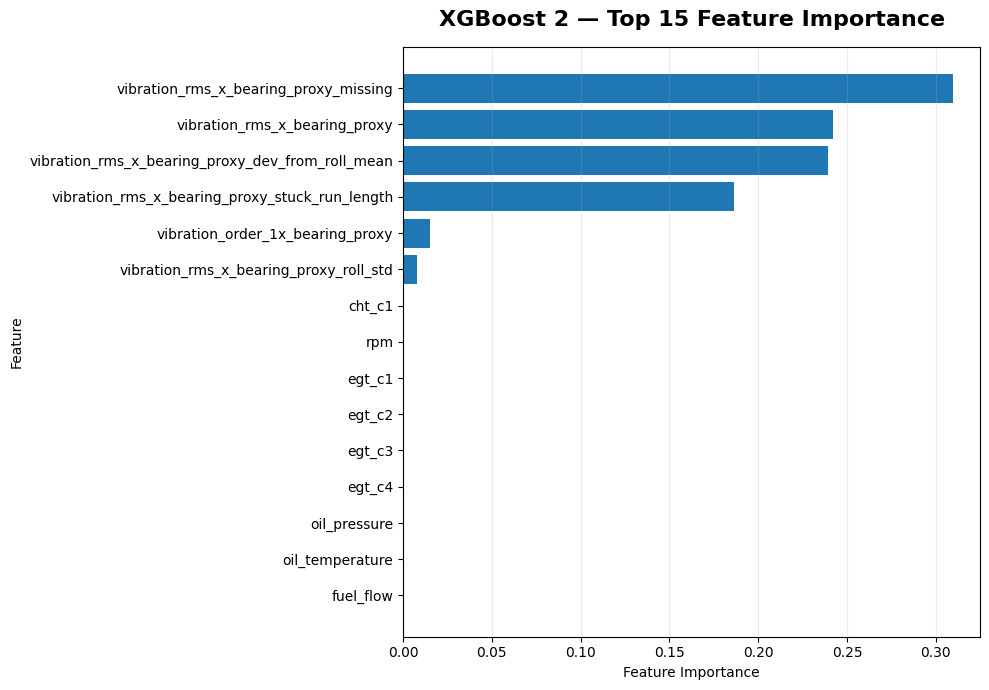


XGBoost 2 — Top 15 Features
                                         Feature  Importance
           vibration_rms_x_bearing_proxy_missing    0.309459
                   vibration_rms_x_bearing_proxy    0.242026
vibration_rms_x_bearing_proxy_dev_from_roll_mean    0.239268
  vibration_rms_x_bearing_proxy_stuck_run_length    0.186169
                vibration_order_1x_bearing_proxy    0.015061
          vibration_rms_x_bearing_proxy_roll_std    0.007839
                                          cht_c1    0.000178
                                             rpm    0.000000
                                          egt_c1    0.000000
                                          egt_c2    0.000000
                                          egt_c3    0.000000
                                          egt_c4    0.000000
                                    oil_pressure    0.000000
                                 oil_temperature    0.000000
                                       fuel_flow    0.00

In [31]:
import matplotlib.pyplot as plt
import pandas as pd

for i, (channel_col, model) in enumerate(
    xgb_models.items(),
    start=1,
):

    importance = model.feature_importances_

    feature_importance_df = pd.DataFrame({
        "Feature": XGB_FEATURE_COLUMNS,
        "Importance": importance,
    }).sort_values(
        "Importance",
        ascending=False,
    )

    top_features = feature_importance_df.head(15)

    plt.figure(figsize=(10, 7))

    plt.barh(
        top_features["Feature"][::-1],
        top_features["Importance"][::-1],
    )

    plt.xlabel("Feature Importance")
    plt.ylabel("Feature")
    plt.title(
        f"XGBoost {i} — Top 15 Feature Importance",
        fontsize=16,
        fontweight="bold",
        pad=15,
    )

    plt.grid(
        axis="x",
        alpha=0.25,
    )

    plt.tight_layout()
    plt.show()

    print(f"\nXGBoost {i} — Top 15 Features")
    print(top_features.to_string(index=False))

In [32]:
# ============================================================
# COMBINED ENGINE FAULT PREDICTION
# XGBoost 1 + XGBoost 2
# ============================================================

predictions = {}

for channel_col, model in xgb_models.items():

    proba = model.predict_proba(X_val)

    pred_xgb = np.argmax(
        proba,
        axis=1,
    )

    inverse_map = target_inverse_maps[channel_col]

    predictions[channel_col] = np.array(
        [
            inverse_map[int(p)]
            for p in pred_xgb
        ],
        dtype=np.int8,
    )


# ------------------------------------------------------------
# Actual validation fault labels
# ------------------------------------------------------------

actual_cht = merged_df.loc[
    ~train_mask,
    "sensor_fault_active_cht_c3",
].astype(int).values

actual_vibration = merged_df.loc[
    ~train_mask,
    "sensor_fault_active_vibration_rms_x_bearing_proxy",
].astype(int).values


# ------------------------------------------------------------
# Combine predictions into ENGINE HEALTH
# ------------------------------------------------------------

pred_cht = predictions[
    "sensor_fault_active_cht_c3"
]

pred_vibration = predictions[
    "sensor_fault_active_vibration_rms_x_bearing_proxy"
]


actual_engine_health = np.where(
    (actual_cht == 0) &
    (actual_vibration == 0),
    0,  # HEALTHY
    1,  # FAULT
)


pred_engine_health = np.where(
    (pred_cht == 0) &
    (pred_vibration == 0),
    0,  # HEALTHY
    1,  # FAULT
)


print("=" * 80)
print("COMBINED ENGINE PREDICTION")
print("=" * 80)

print(
    "\nTotal validation samples:",
    len(pred_engine_health),
)

print(
    "\nActual:"
)

print(
    "ENGINE HEALTHY:",
    np.sum(actual_engine_health == 0),
)

print(
    "ENGINE FAULT:",
    np.sum(actual_engine_health == 1),
)

print(
    "\nPredicted:"
)

print(
    "ENGINE HEALTHY:",
    np.sum(pred_engine_health == 0),
)

print(
    "ENGINE FAULT:",
    np.sum(pred_engine_health == 1),
)

COMBINED ENGINE PREDICTION

Total validation samples: 797785

Actual:
ENGINE HEALTHY: 704658
ENGINE FAULT: 93127

Predicted:
ENGINE HEALTHY: 699517
ENGINE FAULT: 98268


FINAL COMBINED ENGINE EVALUATION

Engine Accuracy: 0.9409
Engine Accuracy: 94.09%

Classification Report:
                precision    recall  f1-score   support

ENGINE HEALTHY       0.97      0.96      0.97    704658
  ENGINE FAULT       0.73      0.77      0.75     93127

      accuracy                           0.94    797785
     macro avg       0.85      0.87      0.86    797785
  weighted avg       0.94      0.94      0.94    797785


Confusion Matrix:
[[678521  26137]
 [ 20996  72131]]


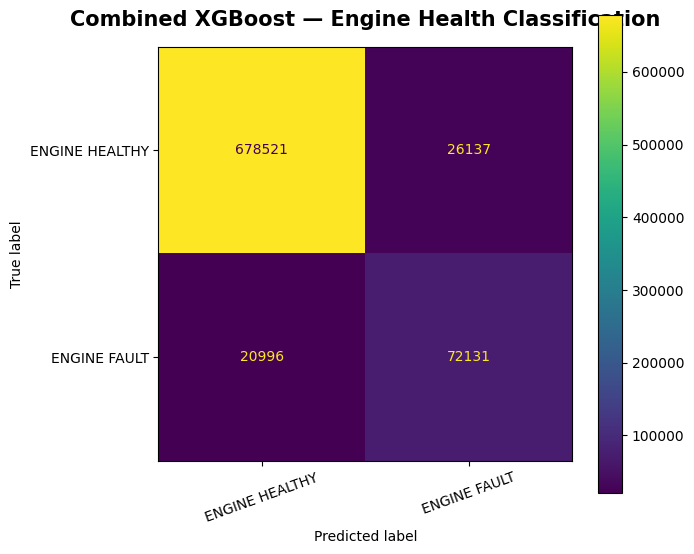

In [34]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
)

# Overall engine accuracy
engine_accuracy = accuracy_score(
    actual_engine_health,
    pred_engine_health,
)

print("=" * 80)
print("FINAL COMBINED ENGINE EVALUATION")
print("=" * 80)

print(f"\nEngine Accuracy: {engine_accuracy:.4f}")
print(f"Engine Accuracy: {engine_accuracy * 100:.2f}%")

print("\nClassification Report:")
print(
    classification_report(
        actual_engine_health,
        pred_engine_health,
        labels=[0, 1],
        target_names=[
            "ENGINE HEALTHY",
            "ENGINE FAULT",
        ],
        zero_division=0,
    )
)

# Confusion matrix
cm = confusion_matrix(
    actual_engine_health,
    pred_engine_health,
    labels=[0, 1],
)

print("\nConfusion Matrix:")
print(cm)

fig, ax = plt.subplots(figsize=(7, 6))

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "ENGINE HEALTHY",
        "ENGINE FAULT",
    ],
).plot(
    ax=ax,
    values_format="d",
    xticks_rotation=20,
)

ax.set_title(
    "Combined XGBoost — Engine Health Classification",
    fontsize=15,
    fontweight="bold",
    pad=15,
)

plt.tight_layout()
plt.show()

In [35]:
MODEL_DIR = f"{ARTIFACTS_DIR}/models"
os.makedirs(MODEL_DIR, exist_ok=True)

# Model 1 — CHT C3
xgb_models[
    "sensor_fault_active_cht_c3"
].save_model(
    f"{MODEL_DIR}/xgboost_cht_c3.json"
)

# Model 2 — Bearing Vibration
xgb_models[
    "sensor_fault_active_vibration_rms_x_bearing_proxy"
].save_model(
    f"{MODEL_DIR}/xgboost_bearing_vibration.json"
)

# Model 3 — Combined Engine
# Save the combined prediction model/config
joblib.dump(
    {
        "model_1": "xgboost_cht_c3.json",
        "model_2": "xgboost_bearing_vibration.json",
    },
    f"{MODEL_DIR}/xgboost_combined_engine.joblib"
)

print("Saved 3 models:")
print(os.listdir(MODEL_DIR))

Saved 3 models:
['xgboost_cht_c3.json', 'xgboost_bearing_vibration.json', 'xgboost_combined_engine.joblib']
